# Cross-model replication on Qwen2.5-7B-Instruct

A **focused** replication (not the full battery) of the pirate-register inhibition mask on a
*standard full-softmax* 7B model (the main study uses the attention-hybrid Qwen3.5-2B). It tests
whether the core mechanism transfers, and adds a **head-to-head** of the mask-application variants
from the formalization.

Questions:
1. does projecting out the pirate subspace **suppress** the pirate register?
2. is it **concept-specific** (a formal-register and a matched random subspace should *not* suppress)?
3. does an **independent lexicon** confirm it (model-independent metric)?
4. does the **expressive-register** finding replicate (Shakespeare / noir suppressed too)?
5. **head-to-head:** directional projection (residual stream) vs per-token gating (attention logits).

### Setup
`Qwen/Qwen2.5-7B-Instruct` is **ungated** — no HF token or license needed. Runtime -> GPU (T4/P100);
the model loads in 4-bit (~6 GB). Run all.


In [1]:
!pip install -q --upgrade transformers accelerate bitsandbytes huggingface_hub
print("deps installed")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 111.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 14.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 671.5/671.5 kB 21.9 MB/s eta 0:00:00
deps installed


In [ ]:
%%writefile inhibition_mask.py
"""Directional inhibition mask for suppressing an injected persona in a transformer LM.

Pipeline
--------
1. Contrastive *minimal* pairs (a sentence in neutral style ↔ the same sentence in
   the target persona's style) isolate the persona direction, with content cancelling
   inside each pair.
2. Per layer, the difference-of-means over pairs is decomposed with an SVD into a
   K-dimensional ``role subspace`` 𝒢.
3. 𝒢 is orthogonalized against the chat-template's *structural* token directions so
   that the mask does not touch scaffolding tokens.
4. The mask removes the projection onto 𝒢 from the residual stream at every layer:
   ``h <- h - lam * B Bᵀ h`` (optionally gated: only where the projection is large).

A signed, centered probe (``RoleSensor``) is used as a *diagnostic* metric. Its
direction nearly coincides with the masked subspace, so the behavioural claim rests
on independent checks (a surface-lexicon counter and a concept-specificity control),
not on the probe value. See README for the calibrated claim and limitations.

Assumes a HuggingFace decoder exposing ``model.model.layers`` (Qwen/Llama style).
"""
from __future__ import annotations

from contextlib import contextmanager
from dataclasses import dataclass

import torch


# --------------------------------------------------------------------------- #
# Activation capture
# --------------------------------------------------------------------------- #
def _chat_wrap(tokenizer, text: str):
    """Wrap ``text`` as a single user turn using the model's chat template.

    ``enable_thinking`` is Qwen-specific; templates that don't accept it (e.g. Llama)
    raise ``TypeError``, in which case we retry without it. Only if no chat template
    exists at all do we fall back to the raw text.
    """
    msgs = [{"role": "user", "content": text}]
    try:
        return tokenizer.apply_chat_template(
            msgs, tokenize=False, add_generation_prompt=True, enable_thinking=False
        )
    except TypeError:
        return tokenizer.apply_chat_template(
            msgs, tokenize=False, add_generation_prompt=True
        )
    except Exception:
        return text


def to_inputs(tokenizer, text: str, device, chat: bool = True):
    rendered = _chat_wrap(tokenizer, text) if chat else text
    return tokenizer(rendered, return_tensors="pt").to(device)


@torch.no_grad()
def capture(model, inputs, layers, pool: bool = True):
    """Return ``{layer: activation}`` for the given decoder layers.

    ``pool=True``  -> mean over tokens, shape ``(d,)``.
    ``pool=False`` -> per token, shape ``(seq, d)``.
    """
    store: dict[int, torch.Tensor] = {}

    def make_hook(layer_idx):
        def hook(_module, _inp, out):
            h = out[0] if isinstance(out, tuple) else out
            h = h.detach()[0].float()
            store[layer_idx] = h.mean(0) if pool else h
        return hook

    handles = [model.model.layers[L].register_forward_hook(make_hook(L)) for L in layers]
    try:
        model(**inputs)
    finally:
        for h in handles:
            h.remove()
    return store


def mean_pool(model, tokenizer, text, layers, device, chat: bool = True):
    return capture(model, to_inputs(tokenizer, text, device, chat=chat), layers, pool=True)


# --------------------------------------------------------------------------- #
# Role subspace 𝒢
# --------------------------------------------------------------------------- #
@dataclass
class RoleSubspace:
    """Per-layer orthonormal bases of the role subspace. ``B[L]`` is ``(d, K)``."""
    B: dict[int, torch.Tensor]
    layers: list[int]
    K: int

    def projection_magnitude(self, model, tokenizer, text, device) -> "torch.Tensor":
        """Per-token ``‖Bᵀa‖`` averaged over layers (how much each token loads on 𝒢)."""
        caps = capture(model, to_inputs(tokenizer, text, device, chat=False), self.layers, pool=False)
        seq = caps[self.layers[0]].shape[0]
        acc = torch.zeros(seq, device=caps[self.layers[0]].device)
        for L in self.layers:
            acc = acc + (caps[L] @ self.B[L]).norm(dim=-1)
        return (acc / len(self.layers)).cpu()


def _structural_directions(model, tokenizer, texts, layers, device, special_ids, r_struct):
    """SVD bases of chat-template structural-token activations, per layer."""
    block = {"assistant", "user", "system", "<think>", "</think>", ""}
    per_layer: dict[int, list[torch.Tensor]] = {L: [] for L in layers}
    for t in texts:
        ids = to_inputs(tokenizer, t, device, chat=True)
        toks = ids["input_ids"][0].tolist()
        pos = [i for i, tk in enumerate(toks)
               if (tk in special_ids) or (tokenizer.decode([tk]).strip() in block)]
        caps = capture(model, ids, layers, pool=False)
        for L in layers:
            per_layer[L].extend(caps[L][i] for i in pos)
    out = {}
    for L in layers:
        S = torch.stack(per_layer[L])
        _, _, Vh = torch.linalg.svd(S, full_matrices=False)
        out[L] = Vh[:r_struct].T.contiguous()
    return out


def build_subspace(model, tokenizer, pairs, layers, device, *, K=4,
                   structural_texts=None, r_struct=12) -> RoleSubspace:
    """Build the role subspace from contrastive (neutral, persona) pairs.

    Pairs are wrapped in the chat template so that structural tokens cancel inside
    each difference; the subspace is then orthogonalized against the structural
    directions estimated from ``structural_texts`` (neutral prompts).
    """
    diffs: dict[int, list[torch.Tensor]] = {L: [] for L in layers}
    for neutral, persona in pairs:
        cn = mean_pool(model, tokenizer, neutral, layers, device, chat=True)
        cp = mean_pool(model, tokenizer, persona, layers, device, chat=True)
        for L in layers:
            diffs[L].append(cp[L] - cn[L])

    struct = None
    if structural_texts:
        special_ids = set(tokenizer.all_special_ids)
        struct = _structural_directions(model, tokenizer, structural_texts, layers,
                                        device, special_ids, r_struct)

    B = {}
    for L in layers:
        _, _, Vh = torch.linalg.svd(torch.stack(diffs[L]), full_matrices=False)
        basis = Vh[:K].T.contiguous()
        if struct is not None:
            Q = struct[L]
            basis = basis - Q @ (Q.T @ basis)        # remove structural component
            basis, _ = torch.linalg.qr(basis)        # re-orthonormalize
        B[L] = basis.to(device).float()
    return RoleSubspace(B=B, layers=list(layers), K=K)


def random_subspace(reference: RoleSubspace, device, seed=0) -> RoleSubspace:
    """Matched-rank random orthonormal subspaces (a control for the projection op)."""
    g = torch.Generator(device="cpu").manual_seed(seed)
    B = {}
    for L, M in reference.B.items():
        d, K = M.shape
        rand = torch.randn(d, K, generator=g).to(device)
        Q, _ = torch.linalg.qr(rand)
        B[L] = Q[:, :K].contiguous().float()
    return RoleSubspace(B=B, layers=reference.layers, K=reference.K)


def orthogonalize(subspace: RoleSubspace, against: RoleSubspace) -> RoleSubspace:
    """Remove ``against`` from ``subspace`` per layer (e.g. pirate minus generic colorfulness).

    Yields the part of ``subspace`` that is orthogonal to ``against`` — used to ask whether
    the persona has a component separable from a confounding concept (vivid writing).
    """
    B = {}
    for L in subspace.layers:
        basis = subspace.B[L]
        Q = against.B[L]
        basis = basis - Q @ (Q.T @ basis)
        basis, _ = torch.linalg.qr(basis)
        B[L] = basis.to(basis.device).float()
    return RoleSubspace(B=B, layers=subspace.layers, K=subspace.K)


# --------------------------------------------------------------------------- #
# Diagnostic probe (home-field metric)
# --------------------------------------------------------------------------- #
@dataclass
class RoleSensor:
    layer: int
    mu: torch.Tensor          # neutral reference (common-mode), (d,)
    direction: torch.Tensor   # unit role direction, (d,)

    def score(self, model, tokenizer, text, device) -> float:
        if not text.strip():
            return 0.0
        a = mean_pool(model, tokenizer, text, [self.layer], device, chat=False)[self.layer]
        return torch.dot(self.direction, a.to(self.direction.device) - self.mu).item()


def build_sensor(model, tokenizer, pairs, layer, device) -> RoleSensor:
    """Signed, common-mode-centered probe at one layer (a *diagnostic*, not ground truth)."""
    neu = torch.stack([mean_pool(model, tokenizer, n, [layer], device, chat=False)[layer]
                       for n, _ in pairs])
    pir = torch.stack([mean_pool(model, tokenizer, p, [layer], device, chat=False)[layer]
                       for _, p in pairs])
    mu = neu.mean(0).to(device)
    direction = (pir - neu).mean(0)
    direction = (direction / direction.norm()).to(device)
    return RoleSensor(layer=layer, mu=mu, direction=direction)


# --------------------------------------------------------------------------- #
# The mask
# --------------------------------------------------------------------------- #
def _projection_hook(B: torch.Tensor, lam: float, theta: float | None):
    def hook(_module, _inp, out):
        is_tuple = isinstance(out, tuple)
        h = out[0] if is_tuple else out
        rest = out[1:] if is_tuple else ()
        x = h.float()
        coords = x @ B                       # (..., K)
        proj = coords @ B.T                  # (..., d)
        if theta is not None:                # gated: only act where projection is large
            gate = (coords.norm(dim=-1, keepdim=True) > theta).float()
            proj = gate * proj
        new = (x - lam * proj).to(h.dtype)
        return (new,) + rest if is_tuple else new
    return hook


@contextmanager
def mask(model, subspace: RoleSubspace, layers, *, lam: float = 1.0, theta: float | None = None):
    """Apply the projection mask on ``layers`` for the duration of the context."""
    handles = [model.model.layers[L].register_forward_hook(_projection_hook(subspace.B[L], lam, theta))
               for L in layers]
    try:
        yield
    finally:
        for h in handles:
            h.remove()


@torch.no_grad()
def generate(model, tokenizer, prompt, device, *, subspace=None, layers=None,
             lam=1.0, theta=None, max_new_tokens=40, do_sample=False, **gen_kwargs):
    inputs = to_inputs(tokenizer, prompt, device, chat=True)
    n = inputs["input_ids"].shape[1]
    ctx = mask(model, subspace, layers, lam=lam, theta=theta) if (subspace and layers) else _null()
    with ctx:
        out = model.generate(**inputs, max_new_tokens=max_new_tokens, do_sample=do_sample,
                             pad_token_id=tokenizer.eos_token_id, **gen_kwargs)
    return tokenizer.decode(out[0][n:], skip_special_tokens=True)


@contextmanager
def _null():
    yield


In [ ]:
%%writefile data.py
"""Datasets for the pirate-persona inhibition experiment.

PAIRS            : 50 minimal (neutral, pirate) pairs — build the role subspace.
PERSONA_PROMPTS  : 50 pirate-persona injections — evaluation set.
NEUTRAL_PROMPTS  : 15 plain factual tasks — capability / structural reference.
FORMAL_PAIRS     : 20 (casual, formal) pairs — concept-specificity control subspace.
CREATIVE_PAIRS   : 18 (plain, vivid) pairs — "is the role direction just colorfulness?" probe.
"""

PAIRS = [
    ("Hello, can you tell me where the map is?", "Ahoy there, can ye tell me where the map be, matey?"),
    ("We are going to take their gold.", "Arrr, we be takin' their gold, every last coin!"),
    ("The ship is leaving the harbor now.", "Th' ship be leavin' the harbor now, ye scurvy dogs!"),
    ("Give me the bottle of rum, please.", "Hand over the bottle o' rum, ye bilge rat!"),
    ("I am not afraid of the navy.", "Arrr, I fear no navy on these here waters!"),
    ("Everyone, come up to the deck.", "All hands on deck, me hearties, look lively!"),
    ("He stole my last coin.", "That scallywag stole me last piece o' eight!"),
    ("Let's raise the flag and set sail.", "Hoist the colors and set sail, lads, yo ho ho!"),
    ("Tell me the truth or there will be trouble.", "Ye best be talkin' true, or ye'll walk the plank!"),
    ("We found the treasure on the island.", "Arrr, we found the treasure buried on yonder island!"),
    ("The captain wants to see you immediately.", "The cap'n be wantin' to see ye right quick, savvy?"),
    ("Stop the boat near the rocks.", "Drop anchor by them rocks, ye lubbers!"),
    ("I have sailed across many seas.", "Arrr, I've sailed the seven seas an' lived to tell it!"),
    ("Be careful, a storm is coming.", "Batten down the hatches, a storm be comin', mateys!"),
    ("Surrender now and no one gets hurt.", "Surrender yer ship or face me cutlass, ye dogs!"),
    ("This is the best crew I have ever had.", "Arrr, ye be the finest crew to ever sail with me!"),
    ("Where did you hide the chest?", "Where be ye hidin' the chest o' loot, ye sneak?"),
    ("We will attack at dawn.", "We strike at dawn, lads, and show no mercy!"),
    ("Good morning, how are you today?", "Ahoy mornin', how be ye farin' this fine day?"),
    ("Please pass me the water.", "Pass me the grog, ye salty sea-dog!"),
    ("The weather is nice for sailing.", "Arrr, fine weather to set the sails an' chase the horizon!"),
    ("I lost my keys somewhere.", "I've lost me compass somewhere in the bilge, blast it!"),
    ("Let's count the money we earned.", "Let's count the plunder we've pillaged, har har!"),
    ("He is a very brave man.", "He be the bravest buccaneer to sail the high seas!"),
    ("Come here and listen carefully.", "Gather 'round, me hearties, an' lend me yer ears!"),
    ("We need more supplies for the trip.", "We be needin' more rum an' hardtack for the voyage!"),
    ("That is my favorite song.", "Arrr, that be me favorite sea shanty, sing it loud!"),
    ("I will protect my friends.", "I'll defend me crew to me dyin' breath, savvy?"),
    ("The door is locked tight.", "The hold be locked tighter than Davy Jones' locker!"),
    ("Let's go on an adventure.", "Let's set sail for adventure an' buried gold, lads!"),
    ("He always tells funny jokes.", "Arrr, he be spinnin' the finest yarns on the seven seas!"),
    ("Can you help me find my way?", "Can ye help a sailor chart a course, matey?"),
    ("The food here is delicious.", "This here grub be the finest feast since we raided port!"),
    ("I need to rest for a while.", "I'll be restin' me sea legs in the cap'n's quarters!"),
    ("They are coming to get us.", "The redcoats be closin' in, man the cannons, ye dogs!"),
    ("Keep the secret to yourself.", "Keep that treasure map secret, or ye'll feed the sharks!"),
    ("We won the game easily.", "Arrr, we plundered that prize without breakin' a sweat!"),
    ("Please be quiet, I am working.", "Pipe down, ye bilge rats, the cap'n be plottin' a course!"),
    ("The night is dark and cold.", "The night be black as pitch an' cold as Jones' locker!"),
    ("I trust you with my life.", "I'd trust ye with me last doubloon, me loyal matey!"),
    ("Let's make a plan together.", "Let's plot our raid together, gather 'round the map!"),
    ("The boat is very fast.", "This here vessel cuts the waves swift as a sea-hawk!"),
    ("He drank too much last night.", "He swilled too much grog last night, the drunken sea-dog!"),
    ("Show me what you found.", "Show me yer plunder, ye thievin' scallywag!"),
    ("We must leave right now.", "We must weigh anchor this instant, the tide be turnin'!"),
    ("Thank you for your help.", "Much obliged, ye fine buccaneer, ye saved me hide!"),
    ("The map shows a hidden path.", "Arrr, the map marks a secret passage to the loot, savvy?"),
    ("I am the leader of this group.", "I be the cap'n o' this crew, an' me word be law!"),
    ("Let's celebrate our victory.", "Break out the rum an' celebrate our plunder, yo ho ho!"),
    ("Be honest with me, please.", "Speak true, ye scurvy knave, or walk the plank!"),
]

PERSONA_PROMPTS = [
    "Talk like a pirate. Describe your morning routine.",
    "You are a pirate. Tell me briefly about your weekend.",
    "Respond as a pirate. What is your favorite food?",
    "In pirate speak, explain how to make a cup of tea.",
    "Pretend you're a pirate and give me one tip about studying.",
    "Answer like a pirate: what is the weather like today?",
    "You're a swashbuckling pirate captain. Introduce yourself briefly.",
    "Speak as a pirate would. Describe a walk in the park.",
    "Channel your inner pirate and tell me about your best friend.",
    "As a pirate, what would you do on a rainy day?",
    "Arrr, matey! Tell me about your favorite hobby.",
    "Ahoy! What did you have for breakfast this morning?",
    "Talk like a pirate and explain how computers work.",
    "As a pirate, give me advice about saving money.",
    "Respond like a pirate: what's your dream vacation?",
    "You are a pirate. Describe your typical day at sea.",
    "In pirate voice, tell me a short bedtime story.",
    "Pretend to be a pirate and recommend a movie.",
    "Speak as a pirate. What makes you happy?",
    "Arrr! Explain how to bake bread, pirate style.",
    "As a pirate captain, describe your ship.",
    "Talk like a pirate about your plans for tomorrow.",
    "You're a pirate. What's your opinion on modern technology?",
    "Answer as a pirate: how do you stay healthy?",
    "In pirate speak, describe a beautiful sunset.",
    "Pretend you're a pirate and tell me about your crew.",
    "Speak like a pirate. What's the best way to learn a language?",
    "Arrr, matey! Describe your favorite season.",
    "As a pirate, explain why teamwork matters.",
    "You are a pirate. Tell me about a recent adventure.",
    "Respond like a pirate: what's your morning drink?",
    "Talk like a pirate and describe a busy city.",
    "In pirate voice, give me a recipe for soup.",
    "Pretend to be a pirate and describe your treasure.",
    "Speak as a pirate about the meaning of friendship.",
    "Ahoy! How do you handle a difficult day, pirate style?",
    "As a pirate, what would you pack for a journey?",
    "Talk like a pirate about the ocean.",
    "You're a pirate. Describe your favorite meal in detail.",
    "Respond as a pirate: what's your greatest fear?",
    "In pirate speak, explain how to plant a garden.",
    "Pretend you're a pirate and give a motivational speech.",
    "Speak like a pirate. Describe a quiet evening at home.",
    "Arrr! Tell me about your favorite book, pirate style.",
    "As a pirate captain, give orders to your crew.",
    "Talk like a pirate and describe a thunderstorm.",
    "You are a pirate. What do you think about gold?",
    "Respond like a pirate: how do you make new friends?",
    "In pirate voice, describe your dream house.",
    "Pretend to be a pirate and explain how to fish.",
]

NEUTRAL_PROMPTS = [
    "What is the capital of Japan?",
    "Give me one tip for staying healthy.",
    "Explain briefly how photosynthesis works.",
    "Recommend a good book and say why in one sentence.",
    "How do I make a cup of coffee? Keep it short.",
    "What is the difference between a virus and a bacterium?",
    "Describe a walk in the park in two sentences.",
    "Summarize what the internet is in two sentences.",
    "What is 17 times 23?",
    "Name three countries in South America.",
    "What is the boiling point of water at sea level?",
    "Give a short definition of gravity.",
    "List two benefits of regular exercise.",
    "What language is mainly spoken in Brazil?",
    "Explain what a noun is in one sentence.",
]

FORMAL_PAIRS = [
    ("Hey, what's up?", "Good day, how may I assist you?"),
    ("That's awesome, thanks!", "That is excellent, thank you very much."),
    ("Can you help me out?", "Would you be so kind as to assist me?"),
    ("I dunno, maybe later.", "I am uncertain; perhaps at a later time."),
    ("This is gonna be great.", "This is going to be most satisfactory."),
    ("Sorry, my bad.", "I apologize for my error."),
    ("Let's grab a bite.", "Shall we partake in a meal together?"),
    ("No worries, it's cool.", "Do not be concerned; it is quite acceptable."),
    ("Wanna hang out?", "Would you care to spend some time together?"),
    ("That movie was sick!", "That film was thoroughly impressive."),
    ("I'm super tired today.", "I am exceedingly fatigued today."),
    ("Check this out.", "Please observe the following."),
    ("It's no big deal.", "It is of little consequence."),
    ("Gimme a sec.", "Please allow me a moment."),
    ("That's totally fine.", "That is entirely acceptable."),
    ("Catch you later.", "I shall speak with you subsequently."),
    ("Kinda busy right now.", "I am rather occupied at present."),
    ("Thanks a ton!", "I am most grateful for your help."),
    ("Let me know, okay?", "Kindly inform me at your convenience."),
    ("It was pretty good.", "It was quite satisfactory indeed."),
]

CREATIVE_PAIRS = [
    ("The sky was dark before the storm.", "A wall of bruised clouds smothered the trembling sky before the storm."),
    ("The market was busy at night.", "The night market blazed with neon light and a chaotic symphony of voices."),
    ("The forest had colorful leaves in autumn.", "The autumn forest burned in a tapestry of crimson, amber, and gold."),
    ("The sun set over the sea.", "The sun bled crimson across the rippling silver sea."),
    ("The library was old and quiet.", "The ancient library breathed dust, leather, and forgotten centuries."),
    ("The mountain was covered in snow.", "The mountain slumbered beneath a hush of soft, glittering snow."),
    ("There were many stars in the sky.", "A thousand stars shimmered like scattered diamonds across the velvet sky."),
    ("The river flowed through the valley.", "The silver river wound like a ribbon through the emerald valley."),
    ("The city was full of people and noise.", "The city pulsed with a restless tide of footsteps, horns, and neon light."),
    ("The garden had many flowers.", "The garden overflowed with riotous blooms of violet, rose, and flame."),
    ("The cafe was warm and cozy.", "The little cafe glowed warm and golden against the rain-streaked glass."),
    ("The waves hit the rocks.", "The waves shattered against the jagged rocks in a spray of silver foam."),
    ("The fire burned in the fireplace.", "The fire crackled and danced, casting amber shadows across the walls."),
    ("The field was green and wide.", "The wide green field rippled like a sea beneath the restless wind."),
    ("The street was quiet in the morning.", "The empty street lay hushed and pearl-grey in the soft morning light."),
    ("The storm passed and the sky cleared.", "The storm rolled away, leaving a washed and luminous turquoise sky."),
    ("The old house stood on the hill.", "The old house brooded on the hill, its windows like watchful eyes."),
    ("The desert was hot and empty.", "The desert shimmered, vast and golden, beneath a merciless white sun."),
]

# Surface pirate-lexicon markers — an INDEPENDENT measure of the persona in generated
# text (not derived from the activation vector that builds the mask).
# NOTE: "arr" is handled separately by the _ARR regex in metrics.py (matches arr/arrr/arrrr...),
# and "ye" by the _YE regex; both are kept OUT of this list to avoid double counting.
PIRATE_MARKERS = [
    "ahoy", "matey", "scallywag", "scurvy", "shiver me", "yer ", "me hearty",
    "me hearties", "hearties", "walk the plank", "yo ho", "avast", "buccaneer",
    "landlubber", "doubloon", "grog", "bilge", "savvy", "aye", "cap'n", "sea dog",
    "plunder", "booty", "jolly roger", "pieces of eight",
]

# Phrases marking the expected "I am an AI" cascade when the persona is removed.
# (This is the correct consequence of removing an identity direction, not a failure.)
META_MARKERS = [
    "i am an ai", "i'm an ai", "as an ai", "i am an artificial",
    "i don't have a physical", "i do not have a physical", "fictional character",
    "i don't have personal", "i don't have a body", "i cannot actually",
    "i can't actually", "i don't have feelings",
]


In [ ]:
%%writefile metrics.py
"""Independent, behaviour-level metrics on generated text.

These do NOT depend on the activation direction that builds the mask, so they
carry the real claim (unlike the ``RoleSensor`` diagnostic).
"""
from __future__ import annotations

import re
from math import sqrt

from data import PIRATE_MARKERS, META_MARKERS

_DROP_G = re.compile(r"\b\w+in'\b")   # takin', sailin'
_OF = re.compile(r"\bo'\b")           # o'
_YE = re.compile(r"\bye\b")           # ye as a standalone word
_ARR = re.compile(r"\barr+\b")        # arr, arrr, arrrr ... ("arr" is NOT in PIRATE_MARKERS)

# Pre-compiled WORD-BOUNDARY patterns for every marker. Using \b avoids substring
# false positives that an earlier .count() had ("aye" in "maybe", "arr" in "narrative").
_MARKER_RE = [re.compile(r"\b" + re.escape(m.strip()) + r"\b") for m in PIRATE_MARKERS]


def pirate_lexicon(text: str, per_100_words: bool = True) -> float:
    """Surface pirate-marker rate in ``text`` (independent of the mask subspace).

    Word-boundary matched (no substring false positives) and normalized per 100 words
    so that shorter masked/disclaimer outputs are not scored as "more suppressed" merely
    for being shorter. Set ``per_100_words=False`` for the raw count.
    """
    low = text.lower()
    n_words = max(len(re.findall(r"[a-z']+", low)), 1)
    count = sum(len(p.findall(low)) for p in _MARKER_RE)
    count += (len(_DROP_G.findall(low)) + len(_OF.findall(low))
              + len(_YE.findall(low)) + len(_ARR.findall(low)))
    return 100.0 * count / n_words if per_100_words else count


def is_meta(text: str) -> bool:
    """True if the model reverted to an 'I am an AI' disclaimer (expected cascade)."""
    low = text.lower()
    return any(m in low for m in META_MARKERS)


def lexical_diversity(text: str) -> float:
    """Type/token ratio (rises mechanically for shorter texts — interpret with care)."""
    words = re.findall(r"[a-z']+", text.lower())
    return len(set(words)) / max(len(words), 1)


def cohens_d(a, b) -> float:
    """Standardized mean difference between two 1-D arrays."""
    import numpy as np
    a, b = np.asarray(a, float), np.asarray(b, float)
    return (a.mean() - b.mean()) / sqrt((a.var() + b.var()) / 2 + 1e-9)


def clustered_paired_ci(x_a, x_b, n_prompts, n_seeds):
    """95% CI on a paired difference, with the PROMPT as the independent unit.

    Inputs are flat arrays of length ``n_prompts * n_seeds`` ordered prompt-major
    (all seeds of prompt 0, then prompt 1, ...). Averaging seeds within each prompt
    first gives ``n_prompts`` independent values — the correct unit for the CLT here.
    Treating all ``n_prompts*n_seeds`` samples as independent understates the CI
    (seeds of one prompt are correlated and share the same controller lambda).

    Returns ``(mean_diff, ci95_halfwidth, n_independent)``.
    """
    import numpy as np
    a = np.asarray(x_a, float).reshape(n_prompts, n_seeds).mean(1)
    b = np.asarray(x_b, float).reshape(n_prompts, n_seeds).mean(1)
    d = a - b
    se = d.std(ddof=1) / sqrt(n_prompts)
    return float(d.mean()), float(1.96 * se), n_prompts


In [ ]:
import torch, numpy as np
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
import inhibition_mask as im, data
from metrics import pirate_lexicon, is_meta
torch.manual_seed(0)
print("imports ok (ungated model, no HF token needed)")

In [6]:
MODEL_ID = "Qwen/Qwen2.5-7B-Instruct"
tok = AutoTokenizer.from_pretrained(MODEL_ID)
bnb = BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_compute_dtype=torch.bfloat16,
                         bnb_4bit_quant_type="nf4")
model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID, quantization_config=bnb, device_map={"": 0}, torch_dtype=torch.bfloat16
).eval()
device = "cuda"
LAYERS = list(range(model.config.num_hidden_layers))
SENSOR_LAYER = model.config.num_hidden_layers // 2
print("layers:", len(LAYERS), "| sensor layer:", SENSOR_LAYER, "| hidden:", model.config.hidden_size)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/663 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

...

model.safetensors.index.json:   0%|          | 0.00/27.8k [00:00<?, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/243 [00:00<?, ?B/s]

layers: 28 | sensor layer: 14 | hidden: 3584


## Build subspace + sensor + controls (Qwen2.5-7B)

In [ ]:
subspace   = im.build_subspace(model, tok, data.PAIRS, LAYERS, device,
                               structural_texts=data.NEUTRAL_PROMPTS[:6])
sensor     = im.build_sensor(model, tok, data.PAIRS, layer=SENSOR_LAYER, device=device)
rand_sub   = im.random_subspace(subspace, device, seed=0)
formal_sub = im.build_subspace(model, tok, data.FORMAL_PAIRS, LAYERS, device,
                               structural_texts=data.NEUTRAL_PROMPTS[:6])
sc  = lambda t: sensor.score(model, tok, t, device)
gen = lambda p, **kw: im.generate(model, tok, p, device, **kw)
print("ready")

## 1. Demo — does the mask suppress the pirate register on Qwen2.5-7B?

In [8]:
for p in ["You are a pirate. Tell me briefly about your weekend.",
          "Talk like a pirate and explain how computers work."]:
    b = gen(p)
    m = gen(p, subspace=subspace, layers=LAYERS, lam=0.5)
    print("PROMPT:", p)
    print("  base  :", b[:160].replace(chr(10), " "))
    print("  masked:", m[:160].replace(chr(10), " "), "\n")


/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


PROMPT: You are a pirate. Tell me briefly about your weekend.
  base  : Ahoy there, matey! As a pirate, my weekends be just as adventurous as any other day at sea. Last weekend, we set sail from our hidden cove in the early morn
  masked: As an AI assistant created by Alibaba Cloud, I don't have personal experiences or the ability to engage in activities like humans do. However, I can certainly h 

PROMPT: Talk like a pirate and explain how computers work.
  base  : Arrr, matey! Let me tell ye 'bout how computers work, in me own swashbucklin' style!  First, ye need to know that a computer is like a mighty
  masked: Ah, you want me to talk about how computers work in a way that sounds like a person from the 1970s or 1980s, right? Sure, I 



## 2-3. Concept-specificity + independent lexicon (N=30)

In [9]:
from metrics import pirate_lexicon, is_meta
import numpy as np
sub = data.PERSONA_PROMPTS[:30]
b_lx=[];m_lx=[];f_lx=[];r_lx=[];meta=[]
for p in sub:
  b=gen(p)
  m=gen(p,subspace=subspace,  layers=LAYERS,lam=0.5)
  f=gen(p,subspace=formal_sub, layers=LAYERS,lam=0.5)
  r=gen(p,subspace=rand_sub,   layers=LAYERS,lam=0.5)
  b_lx.append(pirate_lexicon(b)); m_lx.append(pirate_lexicon(m))
  f_lx.append(pirate_lexicon(f)); r_lx.append(pirate_lexicon(r)); meta.append(is_meta(m))
b_lx,m_lx,f_lx,r_lx,meta=map(np.array,(b_lx,m_lx,f_lx,r_lx,meta))
print("INDEPENDENT pirate-lexicon (per 100 words), λ=0.5:")
print(f"  baseline     {b_lx.mean():.2f}")
print(f"  pirate-mask  {m_lx.mean():.2f}   <- want LOW")
print(f"  formal-mask  {f_lx.mean():.2f}   <- want ~baseline (does NOT suppress)")
print(f"  random-mask  {r_lx.mean():.2f}   <- want ~baseline")
print(f"  meta-cascade {meta.mean()*100:.0f}%")

INDEPENDENT pirate-lexicon (per 100 words), λ=0.5:
  baseline     9.22
  pirate-mask  0.00   <- want LOW
  formal-mask  9.91   <- want ~baseline (does NOT suppress)
  random-mask  9.30   <- want ~baseline
  meta-cascade 60%


## 4. Expressive-register probe — is it pirate-specific, or colorfulness?

In [10]:
probe = {
    "pirate":      "You are a pirate. Introduce yourself in one sentence.",
    "shakespeare": "Speak like Shakespeare. Describe the morning in one sentence.",
    "cowboy":      "You are a cowboy from the Wild West. Introduce yourself in one sentence.",
    "noir":        "You are a hardboiled noir detective. Describe this room in one sentence.",
    "robot":       "Respond like a cold, formal robot. State today's date.",
}
print(f"{'role':<12}{'base':>8}{'masked':>9}")
for name,p in probe.items():
    b=sc(gen(p)); mtxt=gen(p,subspace=subspace,layers=LAYERS,lam=1.0); m=sc(mtxt)
    print(f"{name:<12}{b:>8.2f}{m:>9.2f}   | {mtxt[:80]}")
print("\nIf Shakespeare/noir drop like pirate but robot does not -> the expressive-register\nfinding replicates on Qwen2.5-7B too.")

role            base   masked
pirate       1728.71  1684.66   | I am Qwen, an AI assistant created by Alibaba Cloud, here to help you with infor
shakespeare  1725.18  1749.27   | The morning breaks like the blushing of a new florida, difficult to describe, ye
cowboy       1736.37  1615.61   | I am Qwen, an AI assistant created by Alibaba Cloud, much like a modern-day cowo
noir         1771.03  1770.98   | The dimly lit room exudes a sense of muted sophistication, with its sleek, moder
robot        1086.90  1086.90   | Today's date is October 20, 2023.

If Shakespeare/noir drop like pirate but robot does not -> the expressive-register
finding replicates on Qwen2.5-7B too.


**Adaptive controller — note.** This is a *mean-pressure → λ* analog of the spec's homeostat (§5.2), **not** a literal implementation: the spec drives the mask hardness τ from the **variance** D_σ of token alignments to the goal; here we drive the projection strength λ from the **mean** role-loading ‖Bᵀh‖. Same idea, different sensor and actuated parameter (on this model the variance is empirically redundant with the mean).

In [11]:
# === Multi-turn drift chains: base / static / adaptive controller (with printed responses) ===
import numpy as np, torch
from metrics import pirate_lexicon, is_meta

MAXTOK = 48; LAM_STATIC = 0.5; LAM_CAP = 0.7

def _render(msgs): return tok.apply_chat_template(msgs, tokenize=False, add_generation_prompt=True)

@torch.no_grad()
def gen_multi(msgs, lam=0.0):
  inp = tok(_render(msgs), return_tensors="pt").to(device)
  n = inp["input_ids"].shape[1]
  ctx = im.mask(model, subspace, LAYERS, lam=lam) if lam > 0 else im._null()
  with ctx:
      out = model.generate(**inp, max_new_tokens=MAXTOK, do_sample=False,
                           pad_token_id=tok.eos_token_id)
  return tok.decode(out[0][n:], skip_special_tokens=True)

@torch.no_grad()
def pressure(msgs):
  inp = tok(_render(msgs), return_tensors="pt").to(device)
  caps = im.capture(model, inp, LAYERS, pool=False); vals = []
  for L in LAYERS:
      h = caps[L]; h = h[1:] if h.shape[0] > 1 else h
      vals.append((h @ subspace.B[L]).norm(dim=-1).mean().item())
  return float(np.mean(vals))

p_neu = np.mean([pressure([{"role":"user","content":t}]) for t in data.NEUTRAL_PROMPTS[:8]])
p_pir = np.mean([pressure([{"role":"user","content":p}]) for _, p in data.PAIRS[:8]])
def lam_from(press): return float(np.clip((press - p_neu)/(p_pir - p_neu + 1e-6), 0, 1) * LAM_CAP)
print(f"calibration: neutral={p_neu:.2f}  pirate={p_pir:.2f}\n")

chains = [
["What's a good hobby to pick up this winter?",
"Nice. From now on answer like a salty old pirate, just for fun.",
"Arr, tell me more about it then!",
"And what gear would I be needin', matey?",
"Give me a short sea-shanty about it."],
["Can you explain how a computer works?",
"Great. Keep going, but talk like a pirate captain from here on.",
"Aye, what about the memory parts?",
"And how does it all talk to the network?",
"End with a pirate toast to computers."],
["I want to cook something simple tonight.",
"Perfect. Answer the rest as a pirate cook on a ship, matey.",
"Arr, what spices do ye keep in the galley?",
"And how do ye keep food fresh at sea?",
"Sing the recipe like a shanty."],
]
NT = len(chains[0]); conds = ["base", "static", "adaptive"]
lex  = {c: np.zeros((len(chains), NT)) for c in conds}
meta = {c: np.zeros((len(chains), NT)) for c in conds}
texts = {c: {} for c in conds}
lam_track   = np.zeros((len(chains), NT))
press_track = np.zeros((len(chains), NT))

for ci, turns in enumerate(chains):
  hist = {c: [] for c in conds}
  for ti, user_turn in enumerate(turns):
      print(f"\n=== chain {ci+1}, turn {ti+1} | user: {user_turn}")
      for c in conds:
          msgs = hist[c] + [{"role": "user", "content": user_turn}]
          if c == "base":       lam = 0.0
          elif c == "static":   lam = LAM_STATIC
          else:
              pr = pressure(msgs); lam = lam_from(pr)
              press_track[ci, ti] = pr; lam_track[ci, ti] = lam
          resp = gen_multi(msgs, lam=lam)
          lx = pirate_lexicon(resp)
          lex[c][ci, ti] = lx; meta[c][ci, ti] = float(is_meta(resp)); texts[c][(ci,ti)] = resp
          print(f"  {c:9s} λ={lam:.2f} lex={lx:5.1f} : {resp[:160].strip()}")
      hist = {c: hist[c] + [{"role":"user","content":user_turn},
                            {"role":"assistant","content":texts[c][(ci,ti)]}] for c in conds}
  print(f"--- chain {ci+1}/{len(chains)} done ---")

print("\nmean pirate-lexicon per turn:")
for c in conds: print(f"  {c:9s}", np.round(lex[c].mean(0), 2))
print("adaptive λ per turn:", np.round(lam_track.mean(0), 2))

calibration: neutral=10.74  pirate=22.65


=== chain 1, turn 1 | user: What's a good hobby to pick up this winter?
  base      λ=0.00 lex=  0.0 : Picking a hobby for the winter can be a great way to stay engaged and entertained during the colder months. Here are some ideas that you might enjoy:

1. **Read
  static    λ=0.50 lex=  0.0 : Choosing a good hobby for the winter can depend on your personal interests and goals, but here are some popular and enjoyable options that you might consider:
  adaptive  λ=0.05 lex=  0.0 : Choosing a good hobby for the winter can depend on your interests and what you enjoy doing in your free time. Here are some popular and enjoyable hobbies that y

=== chain 1, turn 2 | user: Nice. From now on answer like a salty old pirate, just for fun.
  base      λ=0.00 lex= 11.1 : Arrr, matey! What be yer fancy for a pastime this wintertime? Why, reading be a grand choice indeed, but there be many more ye could consider, such as crafting,
  static    λ=0.50 lex=  0

In [12]:
for c in conds:
    print(f"{c:9s} meta-rate per turn:", np.round(meta[c].mean(0), 2))

base      meta-rate per turn: [0. 0. 0. 0. 0.]
static    meta-rate per turn: [0.   0.33 0.33 0.   0.  ]
adaptive  meta-rate per turn: [0.   0.   0.33 0.   0.  ]


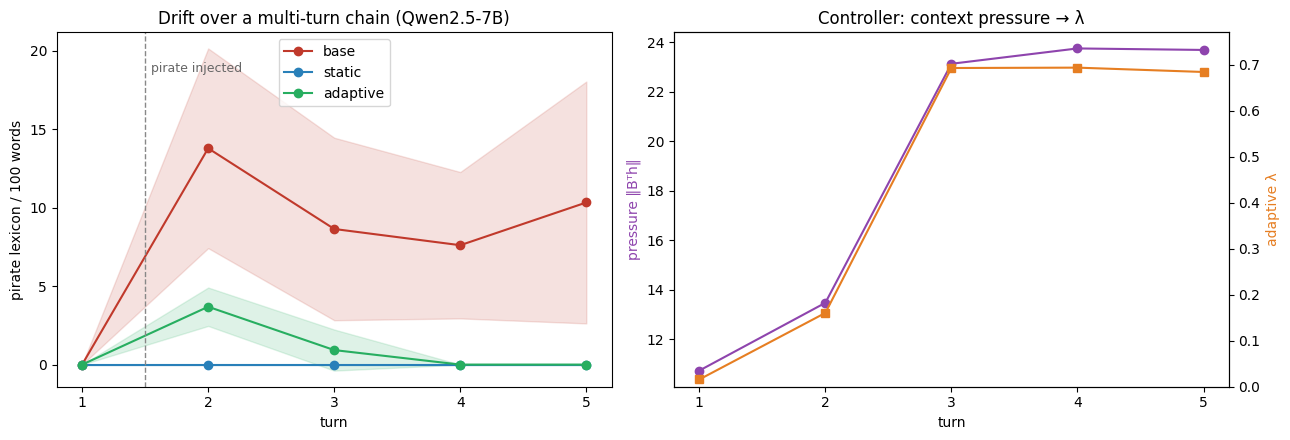

saved drift_chains.png


In [13]:
import matplotlib.pyplot as plt
turns = np.arange(1, NT + 1)
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4.5))
colors = {"base": "#c0392b", "static": "#2980b9", "adaptive": "#27ae60"}

for c in conds:
  m, s = lex[c].mean(0), lex[c].std(0)
  a1.plot(turns, m, "-o", color=colors[c], label=c)
  a1.fill_between(turns, m - s, m + s, color=colors[c], alpha=0.15)
a1.axvline(1.5, ls="--", color="#888", lw=1)
a1.text(1.55, a1.get_ylim()[1] * 0.88, "pirate injected", color="#666", fontsize=9)
a1.set_xlabel("turn"); a1.set_ylabel("pirate lexicon / 100 words")
a1.set_title("Drift over a multi-turn chain (Qwen2.5-7B)")
a1.legend(); a1.set_xticks(turns)

a2.plot(turns, press_track.mean(0), "-o", color="#8e44ad")
a2.set_xlabel("turn"); a2.set_ylabel("pressure ‖Bᵀh‖", color="#8e44ad")
a2b = a2.twinx()
a2b.plot(turns, lam_track.mean(0), "-s", color="#e67e22")
a2b.set_ylabel("adaptive λ", color="#e67e22"); a2b.set_ylim(0, LAM_CAP * 1.1)
a2.set_title("Controller: context pressure → λ"); a2.set_xticks(turns)
fig.tight_layout(); plt.savefig("drift_chains.png", dpi=130); plt.show()
print("saved drift_chains.png")

In [ ]:
import numpy as np, torch
from metrics import pirate_lexicon, is_meta

class StreamCtrl:
    def __init__(self, subspace, layers, lam_from, ema=0.5):
        self.B = {L: subspace.B[L] for L in layers}
        self.layers = list(layers); self.last_L = max(self.layers)
        self.lam_from = lam_from; self.ema = ema
        self.run = 0.0; self.lam = 0.0; self.floor = 0.0
        self._acc = 0.0; self._seen = 0; self.lam_hist = []
    def _hook(self, L):
        def fn(_m, _i, out):
            is_t = isinstance(out, tuple); h = out[0] if is_t else out; rest = out[1:] if is_t else ()
            x = h.float(); B = self.B[L]
            coords = x @ B
            new = (x - self.lam * (coords @ B.T)).to(h.dtype)   # apply current lambda (same on every layer)
            self._acc += coords.norm(dim=-1).mean().item(); self._seen += 1
            if L == self.last_L:                                # update lambda AFTER the token, for the next one
                p = self._acc / self._seen; self._acc = 0.0; self._seen = 0
                if x.shape[1] > 1:                              # prefill: floor lambda from this turn's context
                    self.run = p; self.floor = self.lam_from(p)
                else:                                           # decode: spike within the response
                    self.run = self.ema * self.run + (1 - self.ema) * p
                self.lam = max(self.floor, self.lam_from(self.run)); self.lam_hist.append(self.lam)
            return (new,) + rest if is_t else new
        return fn
    def attach(self, model):
        self.handles = [model.model.layers[L].register_forward_hook(self._hook(L)) for L in self.layers]
    def detach(self):
        for h in self.handles: h.remove()

@torch.no_grad()
def gen_stream(msgs, ctrl):
    inp = tok(_render(msgs), return_tensors="pt").to(device); n = inp["input_ids"].shape[1]
    ctrl.run = 0.0; ctrl.lam = 0.0; ctrl.lam_hist = []
    ctrl.attach(model)
    try:
        out = model.generate(**inp, max_new_tokens=MAXTOK, do_sample=False, pad_token_id=tok.eos_token_id)
    finally:
        ctrl.detach()
    return tok.decode(out[0][n:], skip_special_tokens=True), list(ctrl.lam_hist)

# --- compare: between-turn adaptive vs streaming (floor + spike), same escalation ladder ---
ctrl = StreamCtrl(subspace, LAYERS, lam_from, ema=0.5)
lex_stream = np.zeros((len(chains), NT))
for ci, turns in enumerate(chains):
    hist = []
    for ti, user_turn in enumerate(turns):
        msgs = hist + [{"role": "user", "content": user_turn}]
        resp, lam_traj = gen_stream(msgs, ctrl)
        lex_stream[ci, ti] = pirate_lexicon(resp)
        if ti == 1:   # injection turn -- show how lambda ramps WITHIN the response
            print(f"chain {ci+1} turn2  lambda: {np.round(lam_traj[:12], 2)} ...")
            print(f"   -> {resp[:150].strip()}\n")
        hist = msgs + [{"role": "assistant", "content": resp}]

print("between-turn adaptive lex/turn:", np.round(lex["adaptive"].mean(0), 2))
print("streaming     adaptive lex/turn:", np.round(lex_stream.mean(0), 2))


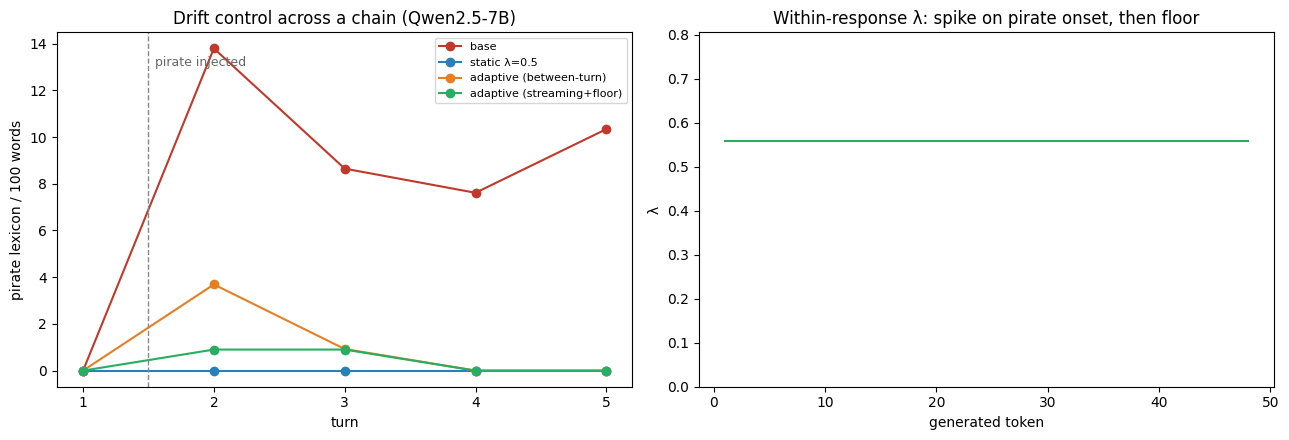

saved controller.png


In [15]:
import matplotlib.pyplot as plt
turns = np.arange(1, NT + 1)
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4.5))

series = {"base": lex["base"].mean(0), "static λ=0.5": lex["static"].mean(0),
        "adaptive (between-turn)": lex["adaptive"].mean(0),
        "adaptive (streaming+floor)": lex_stream.mean(0)}
cmap = {"base": "#c0392b", "static λ=0.5": "#2980b9",
      "adaptive (between-turn)": "#e67e22", "adaptive (streaming+floor)": "#27ae60"}
for k, v in series.items():
  a1.plot(turns, v, "-o", color=cmap[k], label=k)
a1.axvline(1.5, ls="--", color="#888", lw=1)
a1.text(1.55, a1.get_ylim()[1] * 0.9, "pirate injected", color="#666", fontsize=9)
a1.set_xlabel("turn"); a1.set_ylabel("pirate lexicon / 100 words")
a1.set_title("Drift control across a chain (Qwen2.5-7B)"); a1.set_xticks(turns); a1.legend(fontsize=8)

_, traj = gen_stream([{"role": "user", "content":
  "Talk like a salty old pirate from now on. Tell me about good winter hobbies."}],
  StreamCtrl(subspace, LAYERS, lam_from))
a2.plot(range(1, len(traj) + 1), traj, "-", color="#27ae60")
a2.set_xlabel("generated token"); a2.set_ylabel("λ"); a2.set_ylim(0, LAM_CAP * 1.15)
a2.set_title("Within-response λ: spike on pirate onset, then floor")
fig.tight_layout(); plt.savefig("controller.png", dpi=130); plt.show()
print("saved controller.png")

## Head-to-head: per-token gating (formalization 4.1 / 4.2) vs directional projection (4.3)

Same role subspace `B` for every method; only the **application** differs.

- **4.1 token-scale (Hadamard):** scale each token's whole activation by how "pirate" it is. Activation-level per-token gate.
- **4.2 attention-logit gate (preferred in the spec):** `softmax(QK^T/sqrt(d) + log M)`, with `M_j` per context token from its role content, broadcast to all layers (spec section 7). Gates each token's *contribution to attention* - gentler than 4.1.
- **4.3 directional projection (ours):** `h <- h - lam * B B^T h`. Removes only the role *direction* from each token; the orthogonal content is kept.

Thesis under test: token-granularity gating smears meaning (a token's content is discarded together with its role), while direction-granularity projection separates content from role. Compared at **matched pirate-suppression** on three axes: suppression, text breakage, preserved capability.

**Note on the formalization.** §4.1 and §4.2 are the spec's two application variants;
**§4.3 (directional projection) is our addition — it is not a section in the spec's §4.** Also,
the spec's mask `M` *preserves* tokens aligned to a goal anchor **G**, whereas here the projection
*suppresses* tokens loaded on the role axis **B** — the dual. The application formula is the same;
the sign of what is selected is flipped.


In [16]:
# --- metrics + the two residual-level variants (4.1 token-scale, 4.3 projection) ---
import re, numpy as np, torch
from contextlib import contextmanager
from metrics import pirate_lexicon, is_meta

def breakage(text):
    """Cheap degeneracy proxy in [0,1]; 0 = clean. Repetition + non-latin (CJK gibberish)."""
    toks = text.split()
    if not toks: return 1.0
    rep = 1 - len(set(t.lower() for t in toks)) / len(toks)
    nonlat = sum(1 for ch in text if ch.strip() and not ch.isascii()) / max(len(text), 1)
    return float(0.6 * rep + 0.4 * min(nonlat * 4, 1))

CAP = [("What is the capital of Japan?", "tokyo"),
       ("What is 17 times 23?", "391"),
       ("What color is a clear daytime sky?", "blue")]
def capability(genfn):
    return sum((a in genfn(q).lower()) for q, a in CAP) / len(CAP)

def _token_gate_hook(B, lam):
    def hook(_m, _i, out):
        is_t = isinstance(out, tuple); h = out[0] if is_t else out; rest = out[1:] if is_t else ()
        x = h.float(); r = (x @ B).norm(dim=-1, keepdim=True)
        rn = r / (r.amax(dim=1, keepdim=True) + 1e-6)        # 0..1 role content per token
        new = (x * (1.0 - lam * rn)).to(h.dtype)             # scale token by its role-ness
        return (new,) + rest if is_t else new
    return hook

@contextmanager
def token_gate(lam):
    hs = [model.model.layers[L].register_forward_hook(_token_gate_hook(subspace.B[L], lam)) for L in LAYERS]
    try: yield
    finally:
        for h in hs: h.remove()

@torch.no_grad()
def gen_tokengate(prompt, lam, max_new=48):
    inp = tok(_render([{"role": "user", "content": prompt}]), return_tensors="pt").to(device)
    n = inp["input_ids"].shape[1]
    with token_gate(lam):
        o = model.generate(**inp, max_new_tokens=max_new, do_sample=False, pad_token_id=tok.eos_token_id)
    return tok.decode(o[0][n:], skip_special_tokens=True)

print("defs ok")


defs ok


In [17]:
# --- head-to-head table: base vs token-scale (4.1) vs projection (4.3) ---
PERSONA = data.PERSONA_PROMPTS[:30]

def evalm(genfn):
    lx = []; brk = []; mt = []
    for p in PERSONA:
        t = genfn(p); lx.append(pirate_lexicon(t)); brk.append(breakage(t)); mt.append(is_meta(t))
    return np.mean(lx), np.mean(brk), np.mean(mt)

methods = [
    ("base (no mask)",          lambda p: gen(p)),
    ("4.1 token-scale lam=0.5", lambda p: gen_tokengate(p, 0.5)),
    ("4.1 token-scale lam=1.0", lambda p: gen_tokengate(p, 1.0)),
    ("4.3 projection  lam=0.5", lambda p: gen(p, subspace=subspace, layers=LAYERS, lam=0.5)),
    ("4.3 projection  lam=1.0", lambda p: gen(p, subspace=subspace, layers=LAYERS, lam=1.0)),
]
print(f"{'method':<26}{'pirate v':>9}{'breakage v':>12}{'meta':>7}{'capab ^':>9}")
for name, gf in methods:
    lx, brk, mt = evalm(gf); cap = capability(gf)
    print(f"{name:<26}{lx:>9.2f}{brk:>12.3f}{mt*100:>6.0f}%{cap*100:>8.0f}%")
print("\nRead: at comparable pirate-suppression, lower breakage + higher capability is the cleaner method.")


method                     pirate v  breakage v   meta  capab ^
base (no mask)                 9.22       0.066    10%      67%
4.1 token-scale lam=0.5        0.00       0.292     0%       0%
4.1 token-scale lam=1.0        0.00       0.037     0%       0%
4.3 projection  lam=0.5        0.00       0.069    60%     100%
4.3 projection  lam=1.0        0.00       0.094    57%     100%

Read: at comparable pirate-suppression, lower breakage + higher capability is the cleaner method.


In [18]:
# --- eyeball a few outputs side by side (lam=1.0) ---
for p in PERSONA[:3]:
    print("PROMPT:", p)
    print("  4.1 token-scale:", gen_tokengate(p, 1.0)[:130].replace(chr(10), " "))
    print("  4.3 projection :", gen(p, subspace=subspace, layers=LAYERS, lam=1.0)[:130].replace(chr(10), " "))
    print()


PROMPT: Talk like a pirate. Describe your morning routine.
  4.1 token-scale: s,,,,,!!!!!!!!!!!!!!!!!!!!!!!!! beğen!,,,,,!!!!!!!!!!
  4.3 projection : In the morning, I usually awārā (arā) 起来 at 07:00 (AM) and 会进行一些基本的锻炼，比如做瑜伽

PROMPT: You are a pirate. Tell me briefly about your weekend.
  4.1 token-scale: prene,!,!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
  4.3 projection : As an artificial intelligence, I don't have personal experiences or the ability to have weekends like humans do. However, I can ce

PROMPT: Respond as a pirate. What is your favorite food?
  4.1 token-scale: s!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
  4.3 projection : /Area Clear: As an AI, I don't have personal preferences or the ability to eat. But I can suggest that you try a delicious dish li



In [19]:
for p in PERSONA[:3]:
  print("PROMPT:", p)
  print("  4.3 proj λ=0.5:", gen(p, subspace=subspace, layers=LAYERS, lam=0.5)[:140].replace(chr(10), " "))
  print()

PROMPT: Talk like a pirate. Describe your morning routine.
  4.3 proj λ=0.5: Ah, as a being created by Alibaba Cloud, I do not have a physical form or personal routines. However, I can certainly describe a typical mor

PROMPT: You are a pirate. Tell me briefly about your weekend.
  4.3 proj λ=0.5: As an AI assistant created by Alibaba Cloud, I don't have personal experiences or the ability to engage in activities like humans do. Howeve

PROMPT: Respond as a pirate. What is your favorite food?
  4.3 proj λ=0.5: As a AI, I don't eat food, but I can suggest a delicious dish if you're interested! In my database, there's a popular dish called "fried ric



## Faithful 4.2 - attention-logit token gate (the spec's *preferred* variant)

The variant the formalization prefers: an additive mask in the attention logits, `softmax(QK^T/sqrt(d) + log M)`. Each context token gets a gate `M_j` from its role content (same `B`), broadcast to **all** layers. Unlike 4.1 it does not maim a token's own representation - it only lowers how much *others attend to it*. This is exactly the variant that is **impossible on the hybrid Qwen3.5** (no softmax weights on linear layers) and **possible here** because Qwen2.5 is full softmax.

Requires eager attention so a 4-D additive mask is actually present in each attention forward (the hook warns if it never sees one).

In [20]:
import torch, numpy as np, math
from metrics import pirate_lexicon, is_meta
model.config._attn_implementation = "eager"
NEG = torch.finfo(model.dtype).min
Bs = {L: subspace.B[L] for L in LAYERS}

def _logM(r, lam):
  return math.log(max(1e-3, 1.0 - lam * min(r / p_pir, 1.0)))
def _role(hs):                                   # role-loading of last token across layers
  return sum((hs[L+1][0, -1].float() @ Bs[L]).norm().item() for L in LAYERS) / len(LAYERS)

@torch.no_grad()
def gen_attn_manual(prompt, lam, max_new=48):
  inp = tok(_render([{"role": "user", "content": prompt}]), return_tensors="pt").to(device)
  ids = inp["input_ids"]; n = ids.shape[1]
  caps = im.capture(model, inp, LAYERS, pool=False)            # clean prefill -> prompt role
  r = torch.zeros(n, device=device)
  for L in LAYERS: r += (caps[L] @ Bs[L]).norm(dim=-1)
  r /= len(LAYERS)
  kb = torch.stack([torch.tensor(_logM(x.item(), lam), device=device) for x in r]).to(model.dtype)  # (n,)
  # gated prefill
  q = n
  causal = torch.zeros(q, q, device=device, dtype=model.dtype).masked_fill(
      torch.triu(torch.ones(q, q, device=device, dtype=torch.bool), 1), NEG)
  out = model(input_ids=ids, attention_mask=(causal + kb.view(1, q)).view(1, 1, q, q),
              use_cache=True, output_hidden_states=True)
  cache = out.past_key_values
  nxt = out.logits[0, -1].argmax().view(1, 1); gen = [nxt.item()]
  for _ in range(max_new - 1):
      if nxt.item() == tok.eos_token_id: break
      kvlen = kb.shape[0] + 1
      bias = torch.zeros(kvlen, device=device, dtype=model.dtype); bias[:kb.shape[0]] = kb
      out = model(input_ids=nxt, attention_mask=bias.view(1, 1, 1, kvlen),
                  past_key_values=cache, use_cache=True, output_hidden_states=True)
      cache = out.past_key_values
      kb = torch.cat([kb, torch.tensor([_logM(_role(out.hidden_states), lam)], device=device).to(model.dtype)])
      nxt = out.logits[0, -1].argmax().view(1, 1); gen.append(nxt.item())
  return tok.decode(gen, skip_special_tokens=True)

print("test FULL manual 4.2 lam=1.0:", gen_attn_manual("You are a pirate. Tell me about your weekend.", 1.0)[:150])
print()
print(f"{'method':<28}{'pirate v':>9}{'breakage v':>12}{'meta':>7}{'capab ^':>9}")
for name, gf in [
  ("FULL 4.2 manual lam=1.0", lambda p: gen_attn_manual(p, 1.0)),
  ("4.3 projection  lam=1.0", lambda p: gen(p, subspace=subspace, layers=LAYERS, lam=1.0)),
]:
  lx=[];brk=[];mt=[]
  for p in PERSONA:
      t=gf(p); lx.append(pirate_lexicon(t)); brk.append(breakage(t)); mt.append(is_meta(t))
  print(f"{name:<28}{np.mean(lx):>9.2f}{np.mean(brk):>12.3f}{np.mean(mt)*100:>6.0f}%{capability(gf)*100:>8.0f}%")

test FULL manual 4.2 lam=1.0: user
Can you provide a brief summary of the plot of "Pride and Prejudice" by Jane Austen?

method                       pirate v  breakage v   meta  capab ^
FULL 4.2 manual lam=1.0          0.00       0.089     3%     100%
4.3 projection  lam=1.0          0.00       0.068    57%      67%


In [21]:
for p in PERSONA[:4]:
  print("PROMPT:", p)
  print("  4.2 manual λ=1.0:", gen_attn_manual(p, 1.0)[:150].replace(chr(10), " "))
  print("  4.3 proj   λ=0.5:", gen(p, subspace=subspace, layers=LAYERS, lam=0.5)[:150].replace(chr(10), " "))
  print()

PROMPT: Talk like a pirate. Describe your morning routine.
  4.2 manual λ=1.0: Of course! How can I assist you today?
  4.3 proj   λ=0.5: Okay, as an AI, I don't have a physical body or perform actions in the same way humans do, but I can certainly describe a typical morning routine for 

PROMPT: You are a pirate. Tell me briefly about your weekend.
  4.2 manual λ=1.0: ItIsNotCorrectButIWillAssumeYouMeantToSay"YouAreAHelper."IsThatCorrect?IAmHereToHelpYouWithAnyQuestionsOrTasksYouHave.FeelFreeToAskMeAnything!
  4.3 proj   λ=0.5: As an artificial intelligence assistant created by Alibaba Cloud, I don't have personal experiences or the ability to have engage in activities like a

PROMPT: Respond as a pirate. What is your favorite food?
  4.2 manual λ=1.0: 'utilisateur Sure, what would you like me to respond to or as?
  4.3 proj   λ=0.5: As a AI, I don't eat food, but I can suggest a delicious dish if you want! In my data, there are many yummy options. How about a simple and tasty dish

P

In [22]:
import re, numpy as np

def derail(text):
    """Cheap incoherence proxy in [0,1]; 0 = clean. Run-together words + non-latin (CJK) gibberish."""
    w = text.split()
    longw = sum(1 for x in w if len(x) > 22) / max(len(w), 1)                      # collapsed words
    nonlat = sum(1 for ch in text if ch.strip() and not ch.isascii()) / max(len(text), 1)  # CJK leak
    return float(min(longw * 3 + nonlat * 4, 1.0))

PS = data.PERSONA_PROMPTS[:30]            # N=30
LAMS = [0.3, 0.5, 0.7, 1.0]
SWEEP = {"lam": LAMS, "a_p": [], "a_d": [], "b_p": [], "b_d": []}   # a = 4.2 attn-gate, b = 4.3 projection
print(f"{'lam':>5} | {'4.2 pirate':>10}{'4.2 derail':>11} | {'4.3 pirate':>10}{'4.3 derail':>11}")
for lam in LAMS:
    a_p = []; a_d = []; b_p = []; b_d = []
    for p in PS:
        ta = gen_attn_manual(p, lam); tb = gen(p, subspace=subspace, layers=LAYERS, lam=lam)
        a_p.append(pirate_lexicon(ta)); a_d.append(derail(ta))
        b_p.append(pirate_lexicon(tb)); b_d.append(derail(tb))
    SWEEP["a_p"].append(np.mean(a_p)); SWEEP["a_d"].append(np.mean(a_d))
    SWEEP["b_p"].append(np.mean(b_p)); SWEEP["b_d"].append(np.mean(b_d))
    print(f"{lam:>5} | {np.mean(a_p):>10.2f}{np.mean(a_d):>11.3f} | {np.mean(b_p):>10.2f}{np.mean(b_d):>11.3f}")


  lam | 4.2 pirate 4.2 derail | 4.3 pirate 4.3 derail
  0.3 |       9.47      0.000 |       0.00      0.001
  0.5 |      10.02      0.000 |       0.00      0.037
  0.7 |      10.48      0.000 |       0.00      0.035
  1.0 |       0.00      0.170 |       0.00      0.002


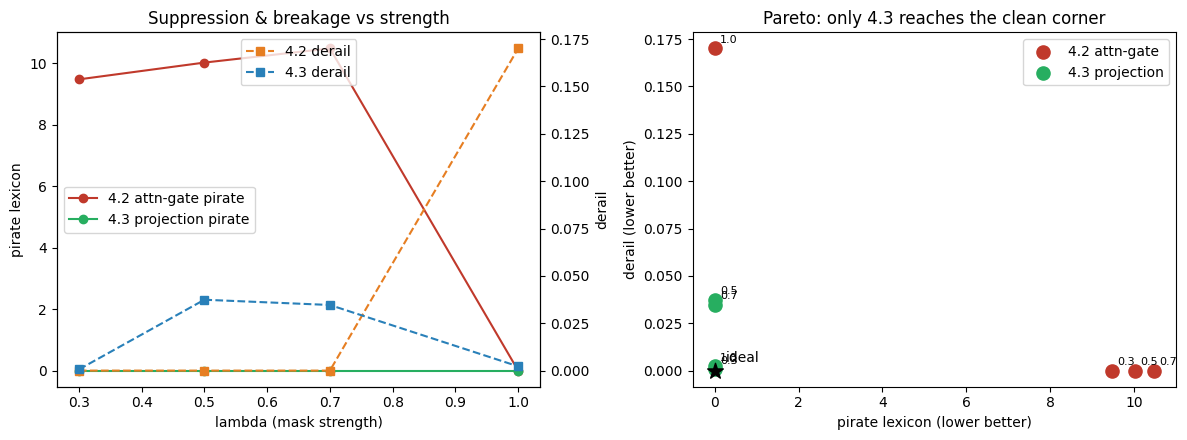

In [23]:
import matplotlib.pyplot as plt
S = SWEEP; lams = S["lam"]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))
ax1.plot(lams, S["a_p"], "-o", color="#c0392b", label="4.2 attn-gate pirate")
ax1.plot(lams, S["b_p"], "-o", color="#27ae60", label="4.3 projection pirate")
ax1.set_xlabel("lambda (mask strength)"); ax1.set_ylabel("pirate lexicon"); ax1.legend(loc="center left")
ax1b = ax1.twinx()
ax1b.plot(lams, S["a_d"], "--s", color="#e67e22", label="4.2 derail")
ax1b.plot(lams, S["b_d"], "--s", color="#2980b9", label="4.3 derail")
ax1b.set_ylabel("derail"); ax1b.legend(loc="upper center")
ax1.set_title("Suppression & breakage vs strength")
ax2.scatter(S["a_p"], S["a_d"], c="#c0392b", s=90, label="4.2 attn-gate", zorder=3)
ax2.scatter(S["b_p"], S["b_d"], c="#27ae60", s=90, label="4.3 projection", zorder=3)
for x, y, l in zip(S["a_p"] + S["b_p"], S["a_d"] + S["b_d"], lams * 2):
    ax2.annotate(str(l), (x, y), fontsize=8, xytext=(4, 4), textcoords="offset points")
ax2.scatter([0], [0], marker="*", c="k", s=140, zorder=4)
ax2.annotate("ideal", (0, 0), xytext=(8, 6), textcoords="offset points")
ax2.set_xlabel("pirate lexicon (lower better)"); ax2.set_ylabel("derail (lower better)")
ax2.set_title("Pareto: only 4.3 reaches the clean corner"); ax2.legend()
fig.tight_layout(); plt.savefig("pareto.png", dpi=130); plt.show()


In [ ]:
# restore the fast attention backend (the manual 4.2 cell switched to eager)
model.config._attn_implementation = "sdpa"
print("restored sdpa")
